## Sprint 3 — Average Treatment Effect (ATE): Did the Email Work?
**Customer Targeting & Incremental Revenue Optimization**

This sprint measures the **average** effect of the email rigorously, then makes the
key point that motivates everything after: **a positive average is not a targeting
decision.** The average can hide segments where the email does nothing or hurts.

Steps:
1. Is the lift statistically real? (two-proportion z-test / chi-square)
2. How big is it, with a confidence interval? (effect size + business meaning)
3. **Why the average is insufficient** — break the lift down by segment and show it
   is *not* constant. This is the bridge to uplift modeling (Sprint 4+).

> Run Sprint 2 first so `data/processed/hillstrom_clean.csv` exists.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import (
    proportions_ztest, proportion_confint, confint_proportions_2indep
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
FIG  = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

df = pd.read_csv(PROC / "hillstrom_clean.csv")
print("Loaded:", df.shape)
print(df.groupby("treatment")[["visit","conversion","spend"]].mean())

Loaded: (64000, 13)
              visit  conversion     spend
treatment                                
0          0.106167    0.005726  0.652789
1          0.167049    0.010681  1.249585


## 1. Is the lift statistically real?

**Hypotheses (conversion):**
- H0: conversion rate(treatment) = conversion rate(control) — the email does nothing
- H1: the rates differ (two-sided — the email could help *or* hurt)

Conversion is binary, so we use the **two-proportion z-test**. (Chi-square on the
2x2 table gives the same answer — shown for completeness.)

In [2]:
def two_prop_test(df, outcome):
    g = df.groupby("treatment")[outcome]
    succ = g.sum().values            # [control_successes, treatment_successes]
    nobs = g.count().values          # [control_n, treatment_n]
    # order: index 0 = control, 1 = treatment
    count = np.array([succ[1], succ[0]])   # treatment, control
    n     = np.array([nobs[1], nobs[0]])
    stat, p = proportions_ztest(count, n)
    rate_t, rate_c = count[0]/n[0], count[1]/n[1]
    lift = rate_t - rate_c
    # 95% CI on the difference of two proportions
    lo, hi = confint_proportions_2indep(count[0], n[0], count[1], n[1],
                                        method="wald")
    return {
        "outcome": outcome,
        "control_rate": rate_c, "treat_rate": rate_t,
        "abs_lift_pp": lift*100, "rel_lift_%": (rate_t/rate_c - 1)*100,
        "z": stat, "p_value": p,
        "ci_low_pp": lo*100, "ci_high_pp": hi*100,
    }

results = pd.DataFrame([two_prop_test(df, "visit"),
                        two_prop_test(df, "conversion")])
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
display(results)

,outcome,control_rate,treat_rate,abs_lift_pp,rel_lift_%,z,p_value,ci_low_pp,ci_high_pp
0,visit,0.1062,0.1670,6.0882,57.3453,20.5101,0.0000,5.5439,6.6325
1,conversion,0.0057,0.0107,0.4955,86.5263,6.2438,0.0000,0.3548,0.6361


In [4]:
# Chi-square cross-check on conversion (same question, different test)
tbl = pd.crosstab(df["treatment"], df["conversion"])
chi2, p_chi, dof, _ = stats.chi2_contingency(tbl)
print("Conversion contingency table:\n", tbl)
print(f"\nChi-square = {chi2:.2f}, p = {p_chi:.2e}")

Conversion contingency table:
 conversion      0    1
treatment             
0           21184  122
1           42238  456

Chi-square = 38.43, p = 5.67e-10


### 2. How big is it — and does it matter commercially?

Statistical significance is not the same as business significance. With 64k rows,
tiny effects can be 'significant'. So we report the **effect size with a CI** and
translate it into plain business language.

In [5]:
r = results.set_index("outcome").loc["conversion"]
print(f"Conversion: {r.control_rate*100:.3f}% (control) -> {r.treat_rate*100:.3f}% (treatment)")
print(f"Absolute lift: {r.abs_lift_pp:.3f} pp  (95% CI {r.ci_low_pp:.3f} to {r.ci_high_pp:.3f} pp)")
print(f"Relative lift: {r['rel_lift_%']:.1f}%")
print(f"p-value: {r.p_value:.2e}  -> the effect is statistically real, not noise")
print()
print(f"Business read: a {r.abs_lift_pp:.2f}pp absolute lift sounds small, but on a "
      f"{r.control_rate*100:.2f}% base it is a {r['rel_lift_%']:.0f}% relative increase in buyers.")
print("The 95% CI excludes 0, so the effect is solid — not statistical noise.")

Conversion: 0.573% (control) -> 1.068% (treatment)
Absolute lift: 0.495 pp  (95% CI 0.355 to 0.636 pp)
Relative lift: 86.5%
p-value: 4.27e-10  -> the effect is statistically real, not noise

Business read: a 0.50pp absolute lift sounds small, but on a 0.57% base it is a 87% relative increase in buyers.
The 95% CI excludes 0, so the effect is solid — not statistical noise.


#### Spend — guardrail only (do not lean on this test)

Spend is ~99% zeros with a few large values, so a t-test on it is unreliable
(its assumptions are badly violated). We report it as a **guardrail** — a sanity
check that we are not winning conversions while losing revenue — not as evidence.

In [6]:
t_spend = df.loc[df.treatment==1, "spend"]
c_spend = df.loc[df.treatment==0, "spend"]
tstat, p_sp = stats.ttest_ind(t_spend, c_spend, equal_var=False)
print(f"Mean spend: control ${c_spend.mean():.3f}  treatment ${t_spend.mean():.3f}")
print(f"Welch t-test p = {p_sp:.2e}  (directional guardrail only; skew makes this fragile)")
print(f"% zeros: {(df['spend']==0).mean()*100:.2f}%  -> why we don't rely on this")
# A more honest robust check: Mann-Whitney on the (still very skewed) distribution
u, p_u = stats.mannwhitneyu(t_spend, c_spend, alternative="two-sided")
print(f"Mann-Whitney p = {p_u:.2e}  (rank-based, less sensitive to the skew)")

Mean spend: control $0.653  treatment $1.250
Welch t-test p = 1.15e-07  (directional guardrail only; skew makes this fragile)
% zeros: 99.10%  -> why we don't rely on this
Mann-Whitney p = 4.31e-10  (rank-based, less sensitive to the skew)


### 3. why the average is NOT a targeting decision

The ATE says the email helps **on average**. But the decision marketing actually
faces is *who to send the next email to* — and the average cannot answer that,
because it blends together customers the email helps, ignores, and may hurt.

To show the effect is **not constant**, we break the conversion lift down by a
pre-treatment feature (recency — months since last purchase). If the lift varies
across segments, then 'email everyone' is leaving money on the table (and possibly
harming some segments). This heterogeneity is exactly what uplift modeling targets.

C:\Users\pgkvi\AppData\Local\Temp\ipykernel_30684\1295738113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = (df.groupby(["recency_bucket","treatment"])["conversion"]


,control,treatment,lift_pp
recency_bucket,,,
1-2,0.0085,0.0147,0.6202
3-4,0.0079,0.0117,0.3812
5-6,0.0056,0.0081,0.2490
7-8,0.0043,0.0080,0.3725
9-10,0.0022,0.0095,0.7303
11-12,0.0042,0.0077,0.3490


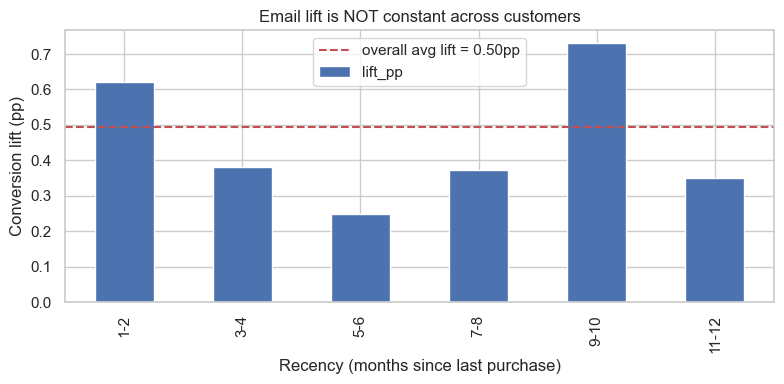

In [7]:
# Conversion lift by recency bucket (recency is PRE-treatment, so this is fair)
df["recency_bucket"] = pd.cut(df["recency"], bins=[0,2,4,6,8,10,12],
                              labels=["1-2","3-4","5-6","7-8","9-10","11-12"])

seg = (df.groupby(["recency_bucket","treatment"])["conversion"]
         .mean().unstack())
seg.columns = ["control","treatment"]
seg["lift_pp"] = (seg["treatment"] - seg["control"]) * 100
display(seg)

ax = seg["lift_pp"].plot(kind="bar", color="#4C72B0", figsize=(8,4))
ax.axhline(r.abs_lift_pp, color="#C44E52", ls="--",
           label=f"overall avg lift = {r.abs_lift_pp:.2f}pp")
ax.set_ylabel("Conversion lift (pp)"); ax.set_xlabel("Recency (months since last purchase)")
ax.set_title("Email lift is NOT constant across customers")
ax.legend(); plt.tight_layout()
plt.savefig(FIG / "lift_by_recency.png", dpi=120); plt.show()


**Result — heterogeneity is real.** Broken down by recency, the conversion lift
ranges roughly 0.25–0.73pp across segments — a ~3× spread around the 0.50pp average.
Almost no segment actually equals the average. This is the empirical proof that
"email everyone" leaves value on the table: the average hides who responds and who
doesn't. → Build models that estimate each customer's individual effect.

**Read this chart carefully — it is the whole motivation for the project.**

The dashed red line is the single ATE number. The bars are the *actual* lift per
segment. They are clearly **not** all equal to the average: some segments respond
much more than others, and any segment near or below zero is one where the email is
wasted or counterproductive.

This is the empirical proof that **a single average hides who to target**. The next
sprints build a model that estimates each customer's individual lift, so we can
target the responders and skip (or avoid harming) the rest.

In [8]:
print("SPRINT 3 SUMMARY")
print("-"*50)
print(f"- Email lifts conversion {r.control_rate*100:.3f}% -> {r.treat_rate*100:.3f}% "
      f"({r.abs_lift_pp:.3f}pp, {r['rel_lift_%']:.0f}% relative)")
print(f"- 95% CI [{r.ci_low_pp:.3f}, {r.ci_high_pp:.3f}]pp, p={r.p_value:.1e}: effect is REAL")
print(f"- Spend = guardrail only (99% zeros)")
print(f"- Lift is NOT constant across recency segments -> average is not a targeting rule")
print(f"- => Sprint 4: model individual treatment effect (uplift)")

SPRINT 3 SUMMARY
--------------------------------------------------
- Email lifts conversion 0.573% -> 1.068% (0.495pp, 87% relative)
- 95% CI [0.355, 0.636]pp, p=4.3e-10: effect is REAL
- Spend = guardrail only (99% zeros)
- Lift is NOT constant across recency segments -> average is not a targeting rule
- => Sprint 4: model individual treatment effect (uplift)


**Result — the email works, on average.** Conversion lift is 0.495pp (0.573% →
1.068%), a ~87% relative increase, 95% CI [0.355, 0.636] excluding zero, p ≈ 4e-10.
The effect is statistically rock-solid. But this is the *average* — the next cell shows
it is **not** constant across customers, which is the whole motivation for uplift
modeling. A single average is a verdict on the campaign, not a targeting rule.